In [1]:
!pip install kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list

Saving kaggle.json to kaggle.json
ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          18723        414                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1449         41                1  
mubashirsidiki/student-academic-performance-500-students            Student Academic Performance - 500 Students               6413  2026-04-07 14:23:4

In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
print(device)

cuda


In [3]:
#!/bin/bash
!kaggle datasets download anhqunhong/fitness-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/anhqunhong/fitness-classification-dataset
License(s): apache-2.0
100% 2.27G/2.27G [02:11<00:00, 18.6MB/s]



In [4]:
!unzip fitness-classification-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: archive/train/labels/crawl_16514.txt  
  inflating: archive/train/labels/crawl_16515.txt  
  inflating: archive/train/labels/crawl_16516.txt  
  inflating: archive/train/labels/crawl_16517.txt  
  inflating: archive/train/labels/crawl_16518.txt  
  inflating: archive/train/labels/crawl_16520.txt  
  inflating: archive/train/labels/crawl_16521.txt  
  inflating: archive/train/labels/crawl_16523.txt  
  inflating: archive/train/labels/crawl_16528.txt  
  inflating: archive/train/labels/crawl_16529.txt  
  inflating: archive/train/labels/crawl_16530.txt  
  inflating: archive/train/labels/crawl_16531.txt  
  inflating: archive/train/labels/crawl_16532.txt  
  inflating: archive/train/labels/crawl_16534.txt  
  inflating: archive/train/labels/crawl_16536.txt  
  inflating: archive/train/labels/crawl_16538.txt  
  inflating: archive/train/labels/crawl_16540.txt  
  inflating: archive/train/labels/crawl_16541.txt  
  inflating: 

In [5]:
import os

for root, dirs, files in os.walk("archive"):
    level = root.replace("archive", "").count(os.sep)
    indent = " "*4*level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 3:
     dirs[:] = []

archive/
    train/
        labels/
        images/
    val/
        labels/
        images/
    test/
        labels/
        images/


In [6]:
import os

label_path = "archive/train/labels"

files = os.listdir(label_path)
print(files[:5])

with open(os.path.join(label_path, files[0]), "r") as f:
  print(f.read())

['crawl_03100.txt', 'crawl_05174.txt', 'crawl_05714.txt', 'crawl_03285.txt', 'crawl_01435.txt']
9


In [7]:
import os

label_path = "archive/train/labels"

classes = set()

for file in os.listdir(label_path):
  with open(os.path.join(label_path, file)) as f :
    classes.add(f.read().strip())

print(classes)
print("Total Classes : ", len(classes))


{'', '4', '2', '0', '9', '1', '5', '6', '3'}
Total Classes :  9


In [8]:
def building_label_map(label_dir):


  all_labels = set()

  for file in os.listdir("archive/train/labels"):
    with open(os.path.join("archive/train/labels",file)) as f:
      label = f.read().strip()

      if label != "":
        all_labels.add(int(label))

  unique_labels = sorted(all_labels)
  label_mapping = {old : new for new, old in enumerate(unique_labels)}

  return label_mapping



In [9]:
from torch.utils.data import Dataset
from PIL import Image
import os

class_map = {
    0 : 0,
    1 : 1,
    2 : 2,
    3 : 3,
    4 : 4,
    5 : 5,
    6 : 6,
    8 : 7,
    9 : 8
}


class GymDataset(Dataset) :
  def __init__(self,image_dir,label_dir,transform=None):
    self.image_dir = image_dir
    self.label_dir = label_dir
    self.transform = transform

    self.label_mapping = building_label_map(label_dir)
    self.files = []

    for img_name in os.listdir(image_dir):
      label_name = img_name.replace(".jpg",".txt")
      label_path = os.path.join(label_dir,label_name)

      if not os.path.exists(label_path):
        continue

      with open(label_path,"r") as f :
        label = f.read().strip()

      if label == "":
        continue
      else :
        label = int(label)

      self.files.append(img_name)

  def __len__(self):
    return len(self.files)

  def __getitem__(self,idx):
    image_name = self.files[idx]
    image_path = os.path.join(self.image_dir,image_name)

    label_name = image_name.replace(".jpg",".txt")
    label_path = os.path.join(self.label_dir,label_name)

    image = Image.open(image_path).convert("RGB")

    with open(label_path,"r") as f :
      label = int(f.read().strip())

    label = self.label_mapping[label]

    if self.transform :
      image = self.transform(image)

    return image, label


In [10]:
# image , label = GymDataset("archive/train/images","archive/train/labels",transform=train_transform)[0]
# print(image.shape)
# print(label)

# for X, y in GymDataset("archive/train/images","archive/train/labels",transform=train_transform):
#   print(X.min())
#   print(y.max())

In [11]:
# from torchvision import transforms

# test_tranform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.ToTensor(),
# ])


# train_dataset = GymDataset("archive/train/images", "archive/train/labels", test_tranform)

# image, label = train_dataset[0]
# print(image.shape)

In [12]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224,padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.4],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.4],
        std=[0.229, 0.224, 0.225]
    )
])



In [13]:
from torch.utils.data import DataLoader

train_dataset = GymDataset("archive/train/images", "archive/train/labels", train_transform)
test_dataset = GymDataset("archive/test/images", "archive/test/labels", test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)


In [14]:
print(train_dataset.label_mapping)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 9: 7}


In [15]:
image, label = train_dataset[0]
print(image.shape)
print(type(image))
print(label)

data = train_dataset[0]
print(type(data))

torch.Size([3, 224, 224])
<class 'torch.Tensor'>
6
<class 'tuple'>


In [16]:
from torchvision import models
import torch.nn as nn

model_rn = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)

model_rn.fc = nn.Linear(model_rn.fc.in_features, 10)

model_rn = model_rn.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


In [17]:
def train_step ( model : nn.Module,
                data_loader : DataLoader,
                 loss_fn : nn.Module,
                 optimizer : torch.optim.Optimizer):

  model.train()

  train_loss, train_acc = 0,0

  for batch,(X,y) in enumerate(data_loader):
    X,y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred,y)

    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    y_pred = y_pred.argmax(dim=1)

    train_acc += (y_pred == y).sum().item()/len(y_pred)

  train_loss = train_loss/len(data_loader)
  train_acc = train_acc/len(data_loader)

  return train_loss, train_acc


def test_step ( model:nn.Module,
               dataloader : DataLoader,
               loss_fn : nn.Module,
                optimizer : torch.optim.Optimizer):

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred = model(X)
      test_loss += loss_fn(test_pred,y).item()

      test_pred = test_pred.argmax(dim=1)
      test_acc += (test_pred == y).sum().item()/len(test_pred)


    test_loss = test_loss/len(dataloader)
    test_acc = test_acc/len(dataloader)

  return test_loss, test_acc

In [18]:
from modulefinder import test
def train(model : nn.Module,
          train_loader : DataLoader,
          test_loader : DataLoader,
          loss_fn : nn.Module,
          optimizer : torch.optim.Optimizer,
          epochs : int = 10):

  results = {
      "train_loss" : [],
      "train_acc" : [],
      "test_loss" : [],
      "test_acc" : []
  }

  for epoch in range(epochs):
    train_loss, train_acc = train_step(model, train_loader, loss_fn, optimizer)
    test_loss, test_acc = test_step(model, test_loader, loss_fn, optimizer)

    if epoch % 10 == 0:

      print( f"Epoch : {epoch} |",
            f"train_loss : {train_loss:.4f} |",
             f"train_acc : {train_acc:.4f} | ",
             f"test_loss : {test_loss:.4f} | ",
             f"test_acc : {test_acc:.4f}")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results


In [19]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_rn.parameters(), lr=0.001)

In [20]:
all_labells = []
empty_labels = []

for files in os.listdir("archive/train/labels"):
  with open(os.path.join("archive/train/labels",files),"r") as f:
    value = f.read().strip()


  if value == "":
    empty_labels.append(files)
  else:
    all_labells.append(int(value))

print(sorted(set(all_labells)))
print(min(all_labells))
print(max(all_labells))

print("empty Labels : ", len(empty_labels))

[0, 1, 2, 3, 4, 5, 6, 9]
0
9
empty Labels :  32


In [21]:
model_rs_results = train(
    model = model_rn,
    train_loader = train_loader,
    test_loader = test_loader,
    loss_fn = loss_fn,
    optimizer = optimizer,
    epochs = 30
)

Epoch : 0 | train_loss : 0.8525 | train_acc : 0.7097 |  test_loss : 0.5795 |  test_acc : 0.8121
Epoch : 10 | train_loss : 0.0636 | train_acc : 0.9801 |  test_loss : 0.1438 |  test_acc : 0.9583
Epoch : 20 | train_loss : 0.0480 | train_acc : 0.9855 |  test_loss : 0.1156 |  test_acc : 0.9724


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
torch.save(model_rn.state_dict(),"/content/drive/MyDrive/gym_exercise_resnet18.pth")

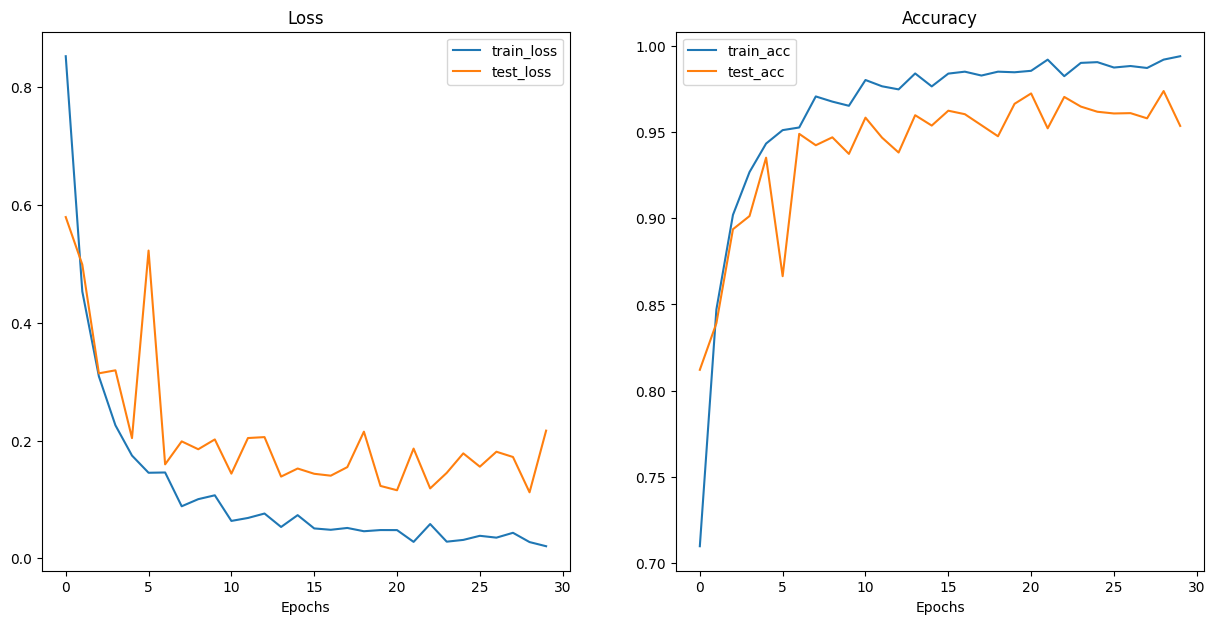

In [25]:
import matplotlib.pyplot as plt


loss = model_rs_results["train_loss"]
test_loss = model_rs_results["test_loss"]

acc = model_rs_results["train_acc"]
test_acc = model_rs_results["test_acc"]

epochs = range(len(loss))

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.plot(epochs,loss,label="train_loss")
plt.plot(epochs,test_loss,label="test_loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs,acc,label="train_acc")
plt.plot(epochs,test_acc,label="test_acc")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.legend()

plt.show()

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = []
y_true = []

model_rn.eval()

with torch.inference_mode():
  for X,y in test_loader :
    X,y = X.to(device), y.to(device)

    logits = model_rn(X)
    y_pred.extend(logits.argmax(dim=1).cpu().numpy())
    y_true.extend(y.cpu().numpy())

print(classification_report(y_true,y_pred))

print(confusion_matrix(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87       147
           1       0.97      0.96      0.96       306
           2       0.96      0.89      0.92       192
           3       0.88      0.96      0.92       224
           4       0.92      0.91      0.91       170
           5       0.94      0.93      0.94       183
           6       0.98      0.98      0.98       827
           7       0.96      0.99      0.97       436

    accuracy                           0.95      2485
   macro avg       0.94      0.93      0.94      2485
weighted avg       0.95      0.95      0.95      2485

[[120   4   2   6   2   1   6   6]
 [  0 293   2   1   0   8   2   0]
 [  1   2 171  10   3   1   2   2]
 [  0   1   0 216   4   0   2   1]
 [  3   0   0  10 155   1   1   0]
 [  1   1   0   2   2 171   1   5]
 [  3   0   2   1   3   0 812   6]
 [  1   1   2   0   0   0   0 432]]


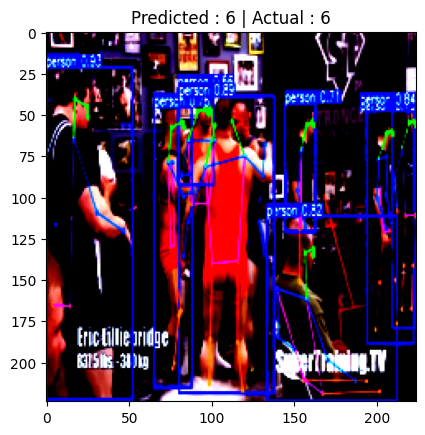

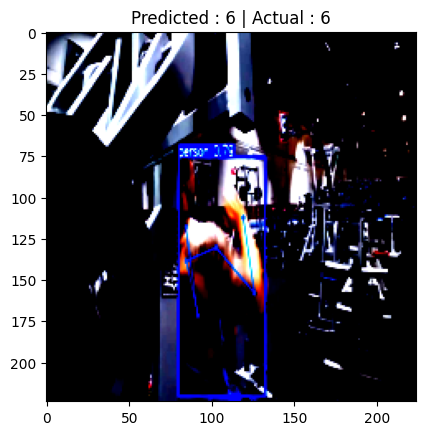

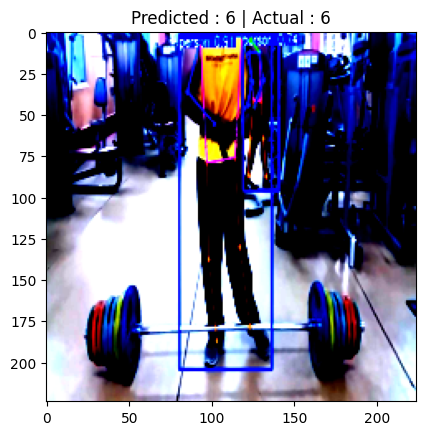

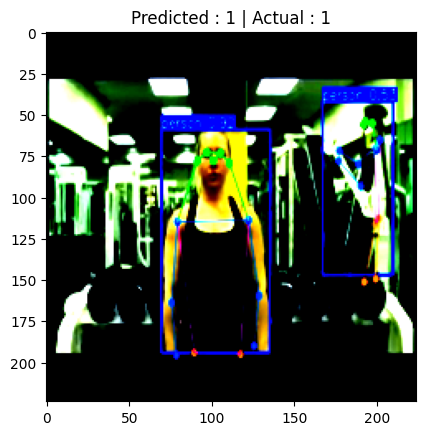

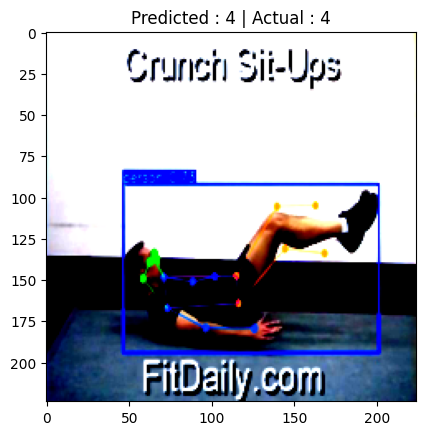

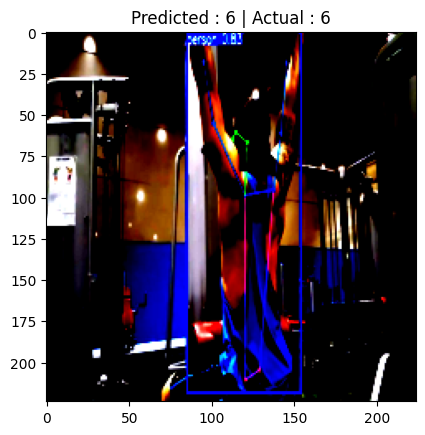

In [27]:
model_rn.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
  outputs = model_rn(images)
  preds = outputs.argmax(dim=1)

images = images.cpu()

for i in range(6) :
  plt.imshow(images[i].permute(1,2,0))
  plt.title(f"Predicted : {preds[i].item()} | Actual : {labels[i].item()}")
  plt.show()

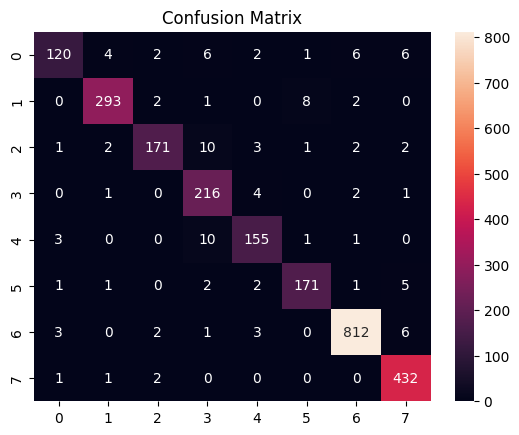

In [28]:
import seaborn as sns


sns.heatmap(confusion_matrix(y_true,y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [29]:
import json
with open("label_mapping.json","w") as f:
  json.dump(train_dataset.label_mapping,f)

<function matplotlib.pyplot.show(close=None, block=None)>

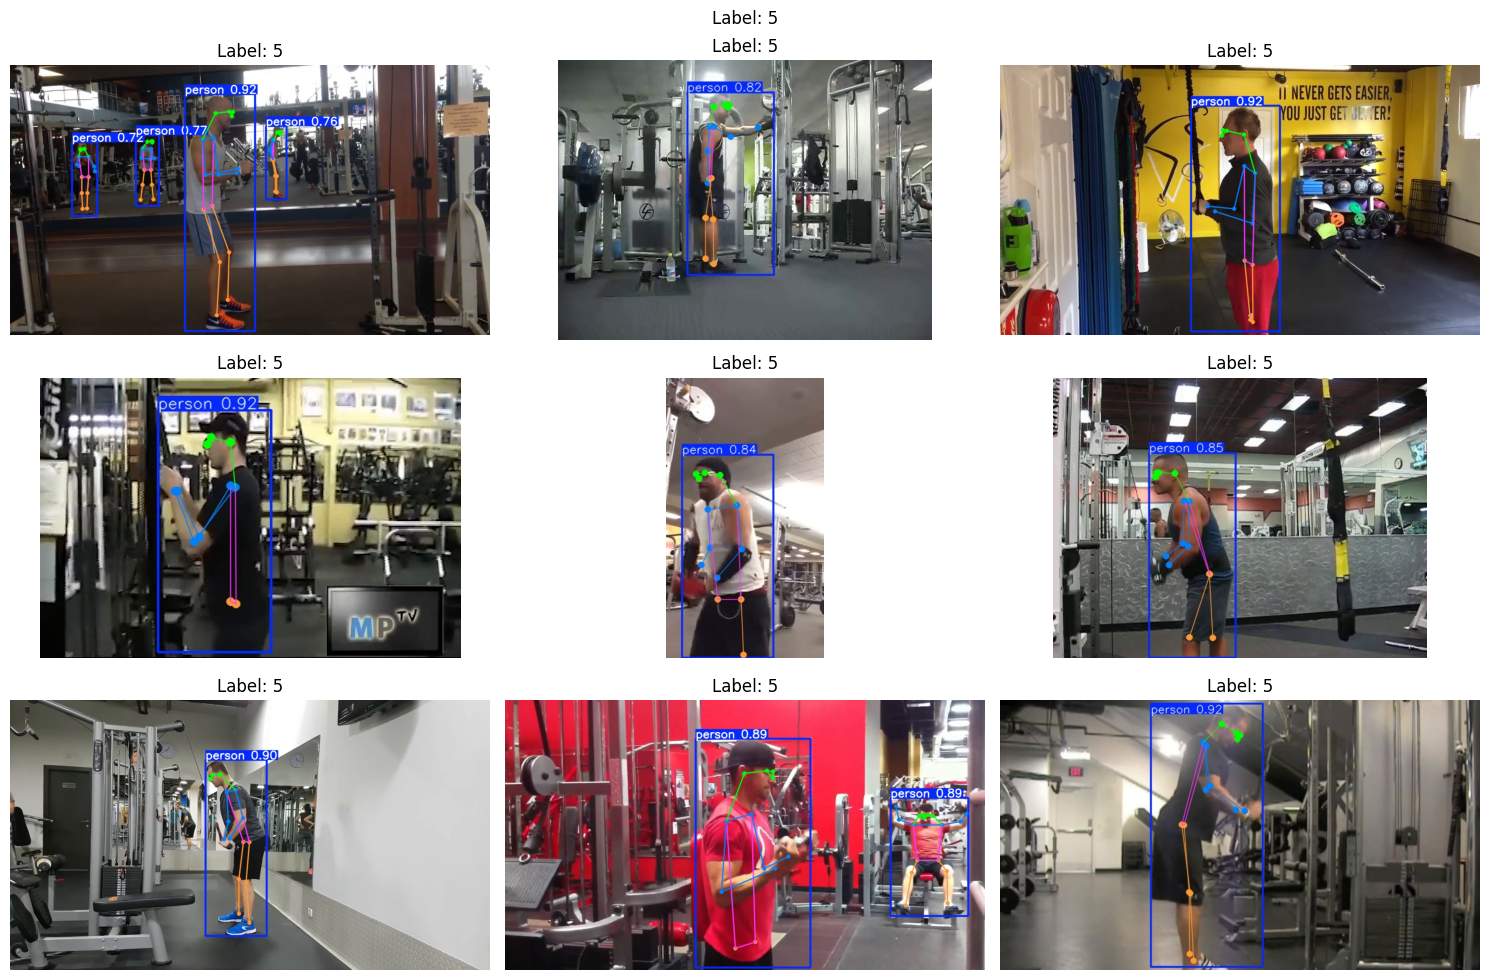

In [30]:
image_dir = "archive/train/images"
label_dir = "archive/train/labels"



plt.figure(figsize=(15,10))

target_label = "5"
count = 0;

for img_name in os.listdir(image_dir):
  label_name = img_name.replace(".jpg",".txt")
  label_path = os.path.join(label_dir,label_name)

  if not os.path.exists(label_path):
    continue

  with open(label_path) as f:
    label = f.read().strip()

  if label == "":
    continue


  if label == target_label :
    img_path = os.path.join(image_dir,img_name)
    image = Image.open(img_path).convert("RGB")

    plt.subplot(3,3,count+1)
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

    count += 1

  if count == 9:
    break

plt.suptitle(f"Label: {target_label}")
plt.tight_layout()

plt.show